In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

from scipy.stats import norm

import matplotlib.pyplot as plt

In [2]:
PROJECT = Path.cwd().parent

HISTORICAL = PROJECT / "data" / "historical"
OPTIONS = PROJECT / "data" / "options"
REPORT = PROJECT / "report"

REPORT.mkdir(exist_ok=True)

# ---------------- SPY ----------------

spy = pd.read_csv(
    HISTORICAL / "SPY_1Y.csv",
    skiprows=[1]
)

# ---------------- HV ----------------

hv_df = pd.read_csv(
    HISTORICAL / "SPY_HistoricalVolatility.csv"
)

# ---------------- Calls ----------------

calls = pd.read_csv(
    OPTIONS / "SPY_Calls_Filtered.csv"
)

# ---------------- VIX ----------------

vix = pd.read_csv(
    HISTORICAL / "VIX_1Y.csv",
    skiprows=[1]
)

print("Data Loaded Successfully")

Data Loaded Successfully


In [6]:
spy_price = float(spy["Close"].iloc[-1])

hv = float(hv_df["HV20"].dropna().iloc[-1])

vix_value = float(vix["Close"].iloc[-1])

print(f"Current SPY Price : {spy_price:.2f}")
print(f"Historical Volatility : {hv:.2f}")
print(f"Current VIX : {vix_value:.2f}")

Current SPY Price : 768.26
Historical Volatility : 0.14
Current VIX : 15.37


In [7]:
calls["Distance"] = abs(calls["strike"] - spy_price)

atm = calls.sort_values("Distance").iloc[0]

strike = atm["strike"]

market_price = atm["lastPrice"]

bid = atm["bid"]

ask = atm["ask"]

volume = atm["volume"]

open_interest = atm["openInterest"]

iv = atm["impliedVolatility"]

print("ATM Option Selected")

print(atm[[
    "contractSymbol",
    "strike",
    "lastPrice",
    "bid",
    "ask",
    "volume",
    "openInterest",
    "impliedVolatility"
]])

ATM Option Selected
contractSymbol       SPY260806C00768000
strike                            768.0
lastPrice                          1.17
bid                                1.16
ask                                1.17
volume                          62077.0
openInterest                       2282
impliedVolatility              0.064218
Name: 61, dtype: object


In [8]:
def black_scholes_call(S, K, T, r, sigma):

    d1 = (
        np.log(S / K)
        + (r + sigma**2 / 2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call = (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return call, d1, d2

In [9]:
# assumptions

risk_free_rate = 0.04

time_to_expiry = 1 / 365

sigma = iv

theoretical_price, d1, d2 = black_scholes_call(
    spy_price,
    strike,
    time_to_expiry,
    risk_free_rate,
    sigma
)

pricing_error = market_price - theoretical_price

print(f"Market Price      : {market_price:.2f}")

print(f"Theoretical Price : {theoretical_price:.2f}")

print(f"Pricing Error     : {pricing_error:.4f}")

Market Price      : 1.17
Theoretical Price : 1.21
Pricing Error     : -0.0412


In [10]:
delta = norm.cdf(d1)

gamma = (
    norm.pdf(d1)
    /
    (
        spy_price
        * sigma
        * np.sqrt(time_to_expiry)
    )
)

vega = (
    spy_price
    * norm.pdf(d1)
    * np.sqrt(time_to_expiry)
    / 100
)

theta = (
    (
        -spy_price
        * norm.pdf(d1)
        * sigma
    )
    /
    (
        2
        * np.sqrt(time_to_expiry)
    )
    -
    risk_free_rate
    * strike
    * np.exp(-risk_free_rate * time_to_expiry)
    * norm.cdf(d2)
) / 365

rho = (
    strike
    * time_to_expiry
    * np.exp(-risk_free_rate * time_to_expiry)
    * norm.cdf(d2)
    / 100
)

print("------------ GREEKS ------------")

print(f"Delta : {delta:.4f}")

print(f"Gamma : {gamma:.6f}")

print(f"Vega  : {vega:.4f}")

print(f"Theta : {theta:.4f}")

print(f"Rho   : {rho:.4f}")

------------ GREEKS ------------
Delta : 0.5537
Gamma : 0.153085
Vega  : 0.1590
Theta : -0.5569
Rho   : 0.0116


In [11]:
iv_percent = iv * 100
hv_percent = hv * 100
iv_hv_spread = iv_percent - hv_percent

bid_ask_spread = ask - bid

print("------------ VOLATILITY ------------")

print(f"Historical Volatility : {hv_percent:.2f}%")
print(f"Implied Volatility    : {iv_percent:.2f}%")
print(f"IV-HV Spread          : {iv_hv_spread:.2f}%")

print()

print("------------ LIQUIDITY ------------")

print(f"Volume        : {volume}")
print(f"Open Interest : {open_interest}")
print(f"Bid           : {bid:.2f}")
print(f"Ask           : {ask:.2f}")
print(f"Bid-Ask Spread: {bid_ask_spread:.2f}")

------------ VOLATILITY ------------
Historical Volatility : 14.29%
Implied Volatility    : 6.42%
IV-HV Spread          : -7.87%

------------ LIQUIDITY ------------
Volume        : 62077.0
Open Interest : 2282
Bid           : 1.16
Ask           : 1.17
Bid-Ask Spread: 0.01


In [12]:
print("------------ STRATEGY ANALYSIS ------------")

# IV-HV Analysis

if iv_hv_spread > 5:
    vol_view = "Options appear relatively expensive."
    strategy = "Option Selling Strategy"
elif iv_hv_spread < -5:
    vol_view = "Options appear relatively inexpensive."
    strategy = "Option Buying Strategy"
else:
    vol_view = "Options appear fairly priced."
    strategy = "Neutral / Wait"

# Liquidity

if (
    volume >= 100
    and open_interest >= 500
    and bid_ask_spread <= 0.05
):
    liquidity = "High"
else:
    liquidity = "Low"

# VIX

if vix_value > 25:
    regime = "High Volatility Market"
elif vix_value > 18:
    regime = "Moderate Volatility Market"
else:
    regime = "Low Volatility Market"

print(vol_view)
print(f"Liquidity : {liquidity}")
print(f"Market Regime : {regime}")
print(f"Suggested Strategy : {strategy}")

------------ STRATEGY ANALYSIS ------------
Options appear relatively inexpensive.
Liquidity : High
Market Regime : Low Volatility Market
Suggested Strategy : Option Buying Strategy


In [13]:
print()

print("=========== SPY OPTION REPORT ===========")

print(f"Current SPY Price        : {spy_price:.2f}")
print(f"Strike                  : {strike:.2f}")

print()

print(f"Market Price            : {market_price:.2f}")
print(f"Theoretical Price       : {theoretical_price:.2f}")
print(f"Pricing Error           : {pricing_error:.4f}")

print()

print(f"Historical Volatility   : {hv:.2f}%")
print(f"Implied Volatility      : {iv_percent:.2f}%")
print(f"IV-HV Spread            : {iv_hv_spread:.2f}%")

print()

print(f"Delta                   : {delta:.4f}")
print(f"Gamma                   : {gamma:.6f}")
print(f"Vega                    : {vega:.4f}")
print(f"Theta                   : {theta:.4f}")
print(f"Rho                     : {rho:.4f}")

print()

print(f"Volume                  : {volume}")
print(f"Open Interest           : {open_interest}")
print(f"Bid                     : {bid:.2f}")
print(f"Ask                     : {ask:.2f}")
print(f"Bid Ask Spread          : {bid_ask_spread:.2f}")

print()

print(f"Market Regime           : {regime}")
print(f"Liquidity               : {liquidity}")
print(f"Recommendation          : {strategy}")

print()

print("Analysis Complete.")


=========== SPY OPTION REPORT ===========
Current SPY Price        : 768.26
Strike                  : 768.00

Market Price            : 1.17
Theoretical Price       : 1.21
Pricing Error           : -0.0412

Historical Volatility   : 0.14%
Implied Volatility      : 6.42%
IV-HV Spread            : -7.87%

Delta                   : 0.5537
Gamma                   : 0.153085
Vega                    : 0.1590
Theta                   : -0.5569
Rho                     : 0.0116

Volume                  : 62077.0
Open Interest           : 2282
Bid                     : 1.16
Ask                     : 1.17
Bid Ask Spread          : 0.01

Market Regime           : Low Volatility Market
Liquidity               : High
Recommendation          : Option Buying Strategy

Analysis Complete.


In [14]:
results = pd.DataFrame({

    "Metric":[
        "SPY Price",
        "Strike",
        "Market Price",
        "Theoretical Price",
        "Pricing Error",
        "HV",
        "IV",
        "IV-HV Spread",
        "Delta",
        "Gamma",
        "Vega",
        "Theta",
        "Rho",
        "Volume",
        "Open Interest",
        "Bid",
        "Ask",
        "Bid Ask Spread",
        "Recommendation"
    ],

    "Value":[
        spy_price,
        strike,
        market_price,
        theoretical_price,
        pricing_error,
        hv,
        iv_percent,
        iv_hv_spread,
        delta,
        gamma,
        vega,
        theta,
        rho,
        volume,
        open_interest,
        bid,
        ask,
        bid_ask_spread,
        strategy
    ]

})

results.to_csv(
    REPORT/"Day45_Report.csv",
    index=False
)

print("CSV Saved.")

CSV Saved.


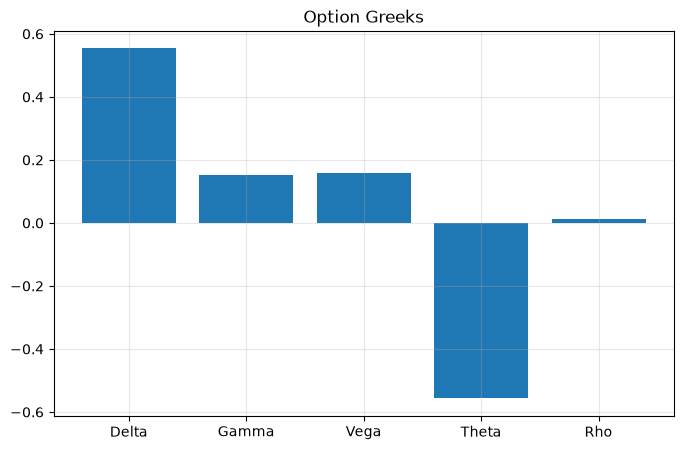

In [18]:
# Greeks

greeks = {
    "Delta":delta,
    "Gamma":gamma,
    "Vega":vega,
    "Theta":theta,
    "Rho":rho
}

plt.figure(figsize=(8,5))

plt.bar(
    greeks.keys(),
    greeks.values()
)

plt.title("Option Greeks")

plt.grid(alpha=0.3)

plt.savefig(

    REPORT /
    "Day45_Greeks.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

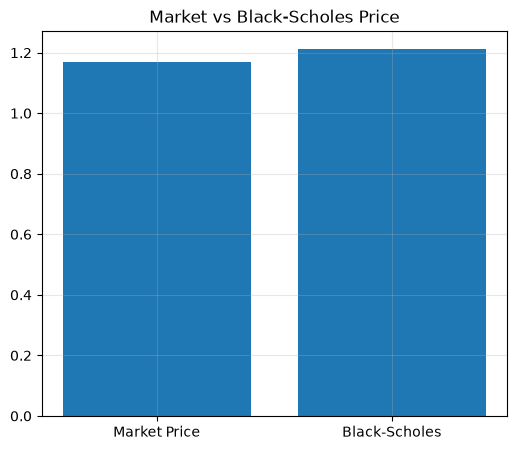

In [19]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Market Price","Black-Scholes"],
    [market_price,theoretical_price]
)

plt.title("Market vs Black-Scholes Price")

plt.grid(alpha=0.3)

plt.savefig(

    REPORT /
    "Day45_Market_vs_Theoretical.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [17]:
print("============== FINAL CONCLUSION ==============")

print()

if strategy == "Option Buying Strategy":

    print(
        "Implied volatility is significantly below historical volatility. "
        "Options appear relatively inexpensive. "
        "Buying options may be favorable if a directional move or increase in volatility is expected."
    )

elif strategy == "Option Selling Strategy":

    print(
        "Implied volatility is significantly above historical volatility. "
        "Options appear relatively expensive. "
        "Option-selling strategies may benefit from time decay and a potential decline in implied volatility."
    )

else:

    print(
        "Implied volatility is close to historical volatility. "
        "Options appear fairly priced. "
        "There is no strong volatility-based edge. Consider waiting for better opportunities or use market direction and Greeks for strategy selection."
    )

print()

print(
    "A professional trader should combine pricing error, IV-HV spread, VIX, "
    "market regime, liquidity, and option Greeks before selecting an options strategy."
)

print()

print("Day 45 Completed Successfully.")

============== FINAL CONCLUSION ==============

Implied volatility is significantly below historical volatility. Options appear relatively inexpensive. Buying options may be favorable if a directional move or increase in volatility is expected.

A professional trader should combine pricing error, IV-HV spread, VIX, market regime, liquidity, and option Greeks before selecting an options strategy.

Day 45 Completed Successfully.
